# FARE package demo

This notebook reproduces the three scenarios and visualizations in `FAREFinalProj-Notebook.ipynb` using the object-oriented `fare_model` package. Install the dependencies with `pip install -e .` when they are not already available.

Each simulation scenario uses the original grid, timestep, runtime, saving cadence, forcing, and model parameters. Full-resolution runs and movie creation can take substantial time.

In [6]:
# DON'T RUN UNLESS YOU'RE CERTAIN YOU WANT TO REINSTALL THESE PACKAGES

%pip install --upgrade --force-reinstall --no-cache-dir "numpy==1.26.4" scipy numba matplotlib opencv-python
%pip install -e ..

^C
Note: you may need to restart the kernel to use updated packages.
Obtaining file:///C:/Users/tydou/Documents/GitHub/FARE-Model-w-Sponge-Terrain
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for fare-model (pyproject.toml): started
  Building editable for fare-model (pyproject.toml): finished with status 'done'
  Created wheel for fare-model: filename=fare_model-0.1.0-0.editable-py3-none-any.whl size=4775 sha256=420b9063adeff78c5168407a9521f22fe2d9de3c8d3769513ca02b22b01e534c
  Stored in directory: C:\Users\tydou\AppData\L

In [5]:
import json
import sys
from pathlib import Path

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from scipy.integrate import cumulative_trapezoid

REPOSITORY_ROOT = Path.cwd().resolve()
while not (REPOSITORY_ROOT / "fare_model").is_dir() and REPOSITORY_ROOT.parent != REPOSITORY_ROOT:
    REPOSITORY_ROOT = REPOSITORY_ROOT.parent
if not (REPOSITORY_ROOT / "fare_model").is_dir():
    raise RuntimeError("Could not find the FARE repository containing fare_model/.")
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

from fare_model import FARE, PhysicalParameters, Scenario, Solution, State, Stats, atmospheric_river, shallow_convection, squall_line
from fare_model.scenarios import coolrate, moistrate

OUTPUT_ROOT = REPOSITORY_ROOT / "output" / "demo"
SAVE_OUTPUT = True
CREATE_MOVIES = True
PARAM = PhysicalParameters()

## Environmental forcing profiles

The package reads the supplied height-dependent moistening and cooling tables from `profiles/`, using PCHIP interpolation and unit conversions.

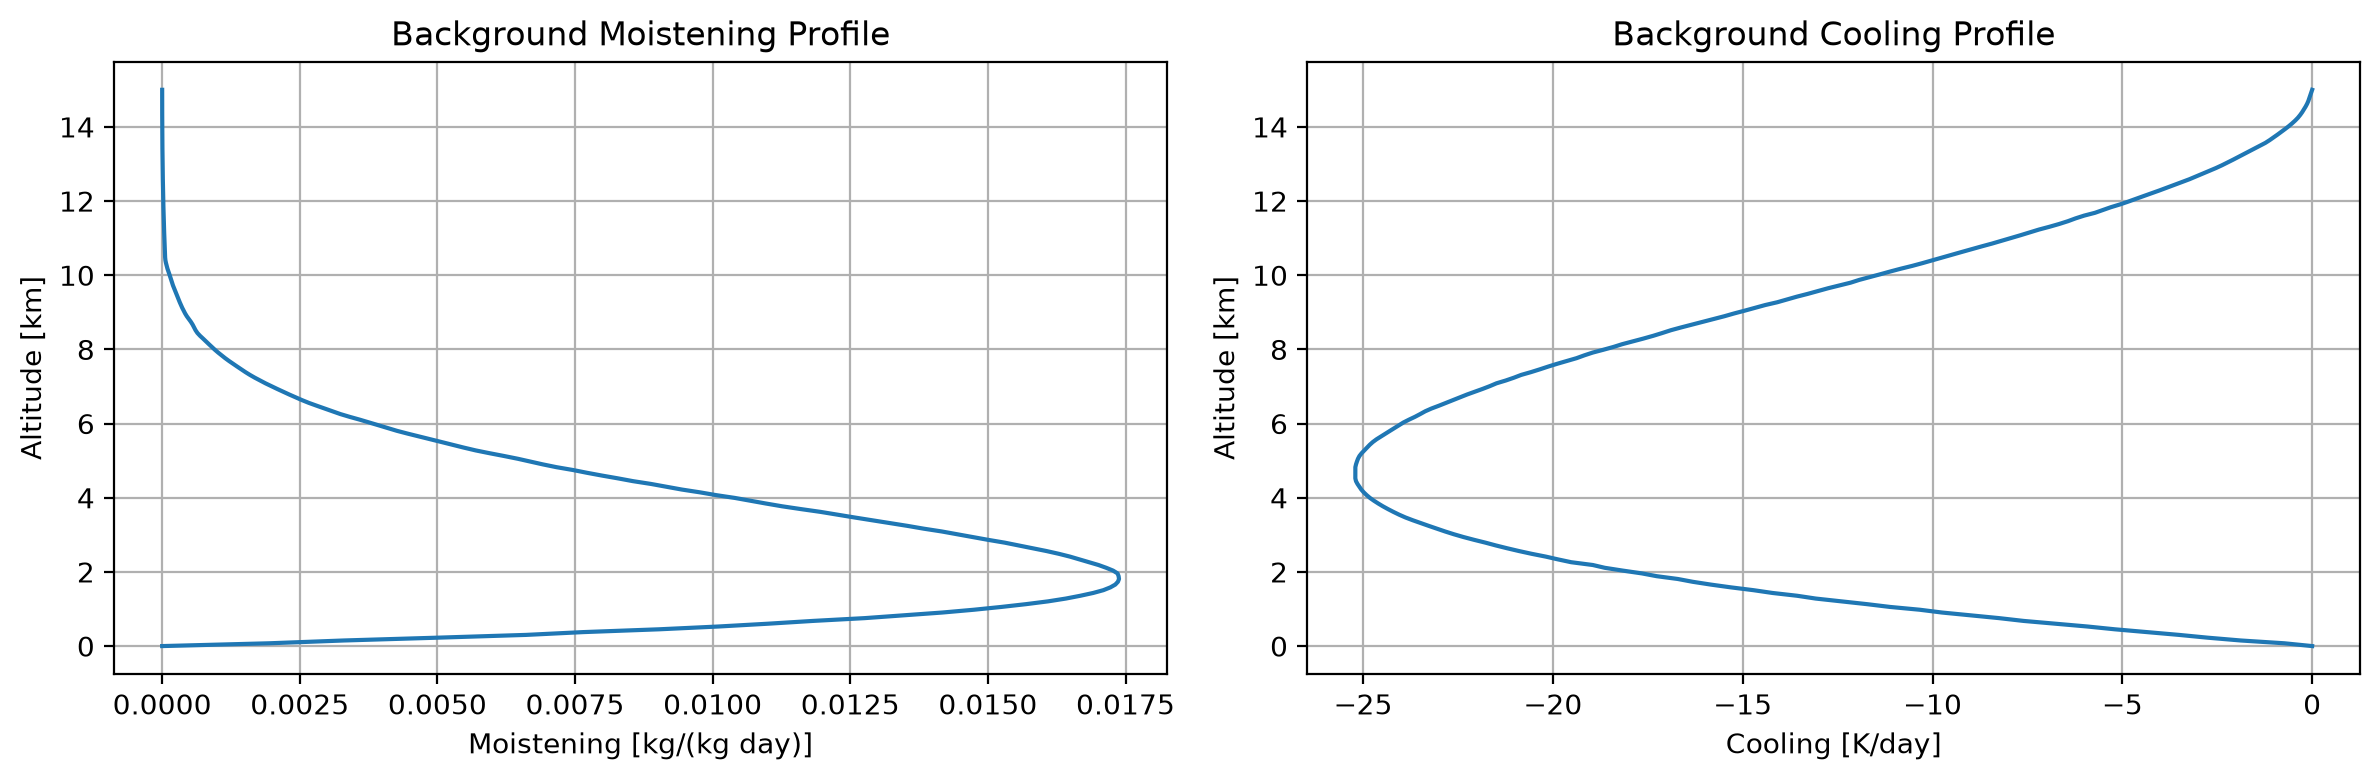

In [2]:
ztau = np.linspace(0, 15000, 200)
moist_int = np.trapz(moistrate(0, ztau), ztau) / 15000
cool_int = np.trapz(coolrate(0, ztau), ztau) / 15000

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=200)
axes[0].plot(moistrate(0, ztau) * 86400, ztau / 1000)
axes[0].set(xlabel="Moistening [kg/(kg day)]", ylabel="Altitude [km]", title="Background Moistening Profile")
axes[0].grid()
axes[1].plot(coolrate(0, ztau) * 86400, ztau / 1000)
axes[1].set(xlabel="Cooling [K/day]", ylabel="Altitude [km]", title="Background Cooling Profile")
axes[1].grid()
fig.tight_layout()

## Scenario definitions

These constructors contain the initial-condition and forcing expressions for each base scenario. The profile functions and the scenarios themselves are also supplied by the package.

In [3]:
def make_shallow_convection() -> Scenario:
    """Create the original notebook's scattered-convection scenario."""
    B = 0.003
    dalr = PARAM.g / PARAM.cp

    def pot0(x, z):
        return PARAM.theta0 + B * z

    def f0(x, z):
        return 1 - dalr / B * np.log1p(B * z / PARAM.theta0)

    def qvi(x, z):
        return 0.018 / f0(x, z) ** PARAM.CpRd * np.exp(-PARAM.LL / PARAM.Rv * (1 / (f0(x, z) * pot0(x, z)) - 1 / PARAM.theta0))

    def poti(x, z):
        field = pot0(x, z)
        x_mask = np.zeros(field.shape[0], dtype=bool)
        x_mask[15:-15] = True
        mask = x_mask[:, np.newaxis] & (z < 2000)
        field[mask] += np.random.uniform(-0.1, 0.1, size=np.sum(mask))
        return field

    return Scenario(poti=poti, qvi=qvi, pot0=pot0, f0=f0, moistening=moistrate, cooling=coolrate, Vt=5, name="shallow_convection")


def make_squall_line() -> Scenario:
    """Create the original notebook's sheared squall-line scenario."""
    B = 0.003
    dalr = PARAM.g / PARAM.cp

    def pot0(x, z):
        return PARAM.theta0 + B * z

    def f0(x, z):
        return 1 - dalr / B * np.log1p(B * z / PARAM.theta0)

    def qvi(x, z):
        return 0.018 / f0(x, z) ** PARAM.CpRd * np.exp(-PARAM.LL / PARAM.Rv * (1 / (f0(x, z) * pot0(x, z)) - 1 / PARAM.theta0))

    def poti(x, z):
        field = pot0(x, z)
        x_mask = np.zeros(field.shape[0], dtype=bool)
        x_mask[30:-30] = True
        mask = x_mask[:, np.newaxis] & (z < 2000)
        field[mask] += np.random.uniform(-0.1, 0.1, size=np.sum(mask))
        return field

    def vertical_shear(x, z):
        H0 = 12000
        a = 11.11
        return np.where(z < H0, a * (np.cos(np.pi * z / H0) - np.cos(2 * np.pi * z / H0)), -2 * a)

    return Scenario(poti=poti, qvi=qvi, pot0=pot0, f0=f0, u_relax=vertical_shear, moistening=moistrate, cooling=coolrate, Vt=5, name="squall_line")


def make_atmospheric_river() -> Scenario:
    """Create the original notebook's atmospheric-river and terrain scenario."""
    dalr = PARAM.g / PARAM.cp

    def pot0(x, z):
        theta_surf = 288.0
        gamma_mbl = 0.001
        gamma_trop = 0.004
        z_inv = 1250.0
        width = 200.0
        smooth_step = width * np.log(np.cosh((z - z_inv) / width)) - width * np.log(np.cosh(-z_inv / width))
        return theta_surf + (gamma_mbl + gamma_trop) * z / 2 + (gamma_trop - gamma_mbl) * smooth_step / 2

    def f0(x, z):
        return 1 + cumulative_trapezoid(-dalr / pot0(x, z), z, axis=-1, initial=0)

    def qvs(x, z):
        return PARAM.qvso / f0(x, z) ** PARAM.CpRd * np.exp(-PARAM.LL / PARAM.Rv * (1 / (f0(x, z) * pot0(x, z)) - 1 / PARAM.theta0))

    def qvi(x, z):
        relative_humidity = 0.10 + 0.85 * 0.5 * (1 - np.tanh((z - 1250) / 200.0))
        return qvs(x, z) * relative_humidity

    def poti(x, z):
        field = pot0(x, z)
        x_mask = np.zeros(field.shape[0], dtype=bool)
        x_mask[30:-30] = True
        mask = x_mask[:, np.newaxis] & (z < 2000)
        field[mask] += np.random.uniform(-0.02, 0.02, size=np.sum(mask))
        return field

    def moistrate2(x, z):
        xmask = 0.5 * (1 + np.tanh((100000 - x) / 10000))
        zmask = 0.5 * (1 - np.tanh((z - 1250) / 160.0))
        return moistrate(x, z) + 20 / (86400 * 1000) * xmask * zmask

    def surface_jet(x, z):
        base_wind = 12 * 0.5 * (1 - np.tanh((z - 3000) / 1000))
        jet_core = 8 * np.exp(-((z - 1100) ** 2) / (2 * 1000 ** 2))
        return base_wind + jet_core

    def mountainshape(x):
        return 1500 * np.exp(-((x - 130000) ** 2) / (2 * 15000 ** 2))

    def mountainmask(x, z):
        h = mountainshape(x)
        z_sigma = 100 + 100 * h / 1250
        raw_mask = 0.5 * (1 - np.tanh((z - h) / z_sigma)) * np.tanh(h / 50)
        return np.where(raw_mask > 0.02, raw_mask, 0)

    def boundarymask(x, z):
        width = 15000
        leftmask = np.where(x < width, 0.5 * (1 + np.cos(np.pi * x / width)), 0)
        rightmask = np.where(x > 256000 - width, 0.5 * (1 + np.cos(np.pi * (256000 - x) / width)), 0)
        topmask = 0.5 * (1 + np.tanh((z - 9000) / 1000))
        return 1 - (1 - leftmask) * (1 - rightmask) * (1 - topmask)

    return Scenario(poti=poti, qvi=qvi, pot0=pot0, f0=f0, u_relax=surface_jet, moistening=moistrate2, cooling=coolrate, spongelayer=boundarymask, terrainmask=mountainmask, terrain_height=mountainshape, tauM=50, tauS=200, Vt=6, name="atmospheric_river")

## Run scenarios (if no pre-existing session)

### Shallow convection

In [7]:
shallow = (
    FARE(PARAM)
    .set_grid(L=(256000, 15000), grid=(257, 100), dt=2.2, T=22000, s=20)
    .set_comp(explicit_scheme="AB3")
    .set_scenario(shallow_convection())
    .set_state()
)
shallow.solve(save=SAVE_OUTPUT, output_dir=OUTPUT_ROOT / "shallow_convection" if SAVE_OUTPUT else None)
shallow

Save 500/500 | 100.00% complete


### Squall line

In [ ]:
squall = (
    FARE(PARAM)
    .set_grid(L=(256000, 15000), grid=(257, 100), dt=2.2, T=148500, s=20)
    .set_comp(explicit_scheme="AB3")
    .set_scenario(squall_line())
    .set_state()
)
squall.solve(save=SAVE_OUTPUT, output_dir=OUTPUT_ROOT / "squall_line" if SAVE_OUTPUT else None)
squall

### Atmospheric river

In [ ]:
profile = atmospheric.scenario
ztest = np.linspace(0, 9000, 100)
wind = profile.u_relax(0, ztest)
moisture = profile.moistening(0, ztest)
humidity = profile.qvi(0, ztest)
temperature = profile.pot0(0, ztest)

fig, ax = plt.subplots(dpi=200)
ax.plot(wind / np.max(wind), ztest / 1000, color="grey", label="u velocity (max 20 m/s)")
ax.plot(moisture / np.max(moisture), ztest / 1000, color="blue", label=f"Moisture forcing (max {np.max(moisture) * 1000 * 86400:.1f} g/kg/day)")
ax.plot(humidity / np.max(humidity), ztest / 1000, color="skyblue", label=f"Initial moisture (max {np.max(humidity) * 1000:.1f} g/kg)")
ax.plot((temperature - 290) / (np.max(temperature) - 290), ztest / 1000, color="red", label="Background potential temperature")
ax.set(xlabel="Normalized values", ylabel="Altitude [km]", title="Initial & Forcing Profiles")
ax.legend(loc="upper left")
ax.grid()
if SAVE_OUTPUT:
    fig.savefig(OUTPUT_ROOT / "atmospheric_river" / "initial_forcing_profiles.png", dpi=200, bbox_inches="tight")

In [ ]:
atmospheric = (
    FARE(PARAM)
    .set_grid(L=(256000, 12000), grid=(257, 200), dt=1.1, T=80000, s=40)
    .set_comp(explicit_scheme="AB3")
    .set_scenario(atmospheric_river())
    .set_state()
)
atmospheric.solve(save=SAVE_OUTPUT, output_dir=OUTPUT_ROOT / "atmospheric_river" if SAVE_OUTPUT else None)
atmospheric

## Load an existing session

Run this section by changing session_dir to a path that contains saves from a previous session. 

To run the simulation from an established state, you may use `state.npz` for initial conditions and `metadata.json` to recall the previously-used computational parameters. To save and visualize the full session as one continuum, you will also need `solution.npz` and `stats.npz`, otherwise it will overwrite the past session with the current session.

In [8]:
session_dir = OUTPUT_ROOT / "shallow_convection"
metadata = json.loads((session_dir / "metadata.json").read_text(encoding="utf-8"))

loaded_shallow = (
    FARE(PARAM)
    .set_grid(L=metadata["L"], grid=metadata["grid"], dt=metadata["dt"], T=metadata["T"], s=metadata["s"])
    .set_comp(explicit_scheme=metadata["explicit_scheme"])
    .set_scenario(shallow_convection())
    .set_state()
)

with np.load(session_dir / "state.npz") as archive:
    loaded_shallow.state = State(
        **{name: archive[name] for name in ("P", "pot", "qt", "qr", "u", "w", "uRHS", "wRHS", "potRHS", "qtRHS")},
        n=int(archive["n"]),
        m=int(archive["m"]),
    )

with np.load(session_dir / "solution.npz") as archive:
    loaded_shallow.sol = Solution(
        **{name: archive[name] for name in ("t_s", "x", "z", "P_s", "pot_s", "pot_r_s", "u_s", "w_s", "qv_s", "qr_s")},
        count=len(archive["t_s"]),
    )

with np.load(session_dir / "stats.npz") as archive:
    loaded_shallow.stats = Stats(
        **{name: archive[name] for name in ("cons_potr", "cons_pote", "cons_pot", "cons_qt", "cons_qr", "cons_qv", "cons_K", "cons_B", "cons_R", "C", "w_max", "temp_max")},
        count=len(archive["C"]),
    )

loaded_shallow
# Example continuation: loaded_shallow.continue_solve(1000, save=True, output_dir=session_dir)

## Temperature/velocity and combined rain/vapor animations

The package methods write the temperature/velocity movie and the combined rain/vapor movie. `CREATE_MOVIES` can be set to `False` when only the simulation archives and static figures are wanted.

For the example case used, note that the first 1-2 hours essentially serve as a wind-up to properly perturb the system and aren't representative of any standard, long-term dynamics. This wind-up time varies by system.

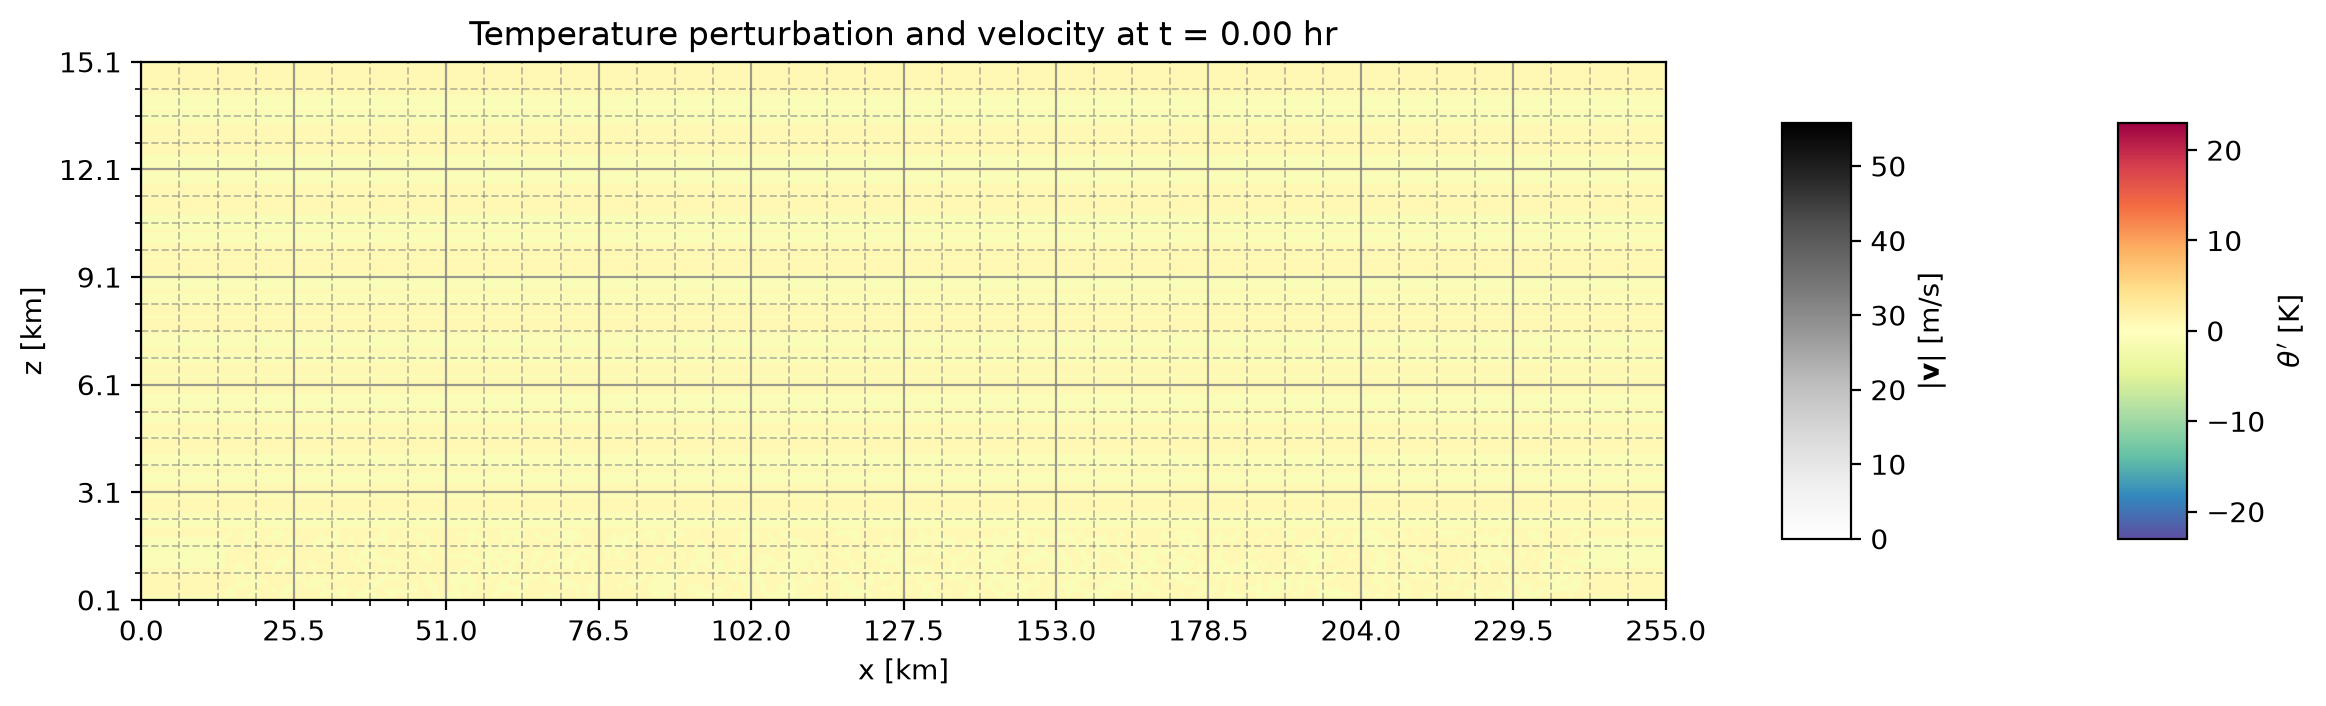

In [ ]:
from IPython.display import Video, display

movie_dir = OUTPUT_ROOT / "shallow_convection"
if CREATE_MOVIES:
    temperature_animation = loaded_shallow.animate_temperature_velocity(save=True, output_dir=movie_dir, filename="Mount_1_Temperature.mp4", z_cut=125, frames=slice(None, 1001, 2))
    rainvapor_animation = loaded_shallow.animate_rainvapor(save=True, output_dir=movie_dir, filename="Mount_1_RainVapor.mp4", z_cut=125, frames=slice(None, 1001, 2))
    display(Video(filename=str(movie_dir / "Mount_1_Temperature.mp4"), embed=True, width=720, height=480))
    display(Video(filename=str(movie_dir / "Mount_1_RainVapor.mp4"),embed=True, width=720,height=480))

## Conservation and stability figures

In [ ]:
conservation_figure = atmospheric.plot_conservation_stability(save=SAVE_OUTPUT, output_dir=movie_dir, filename="Mount_Stats.png")

count = min(atmospheric.sol.count, atmospheric.stats.count)
time = atmospheric.sol.t_s[:count]
area = np.prod(atmospheric.numerics.L)
rain_energy_integral = cumulative_trapezoid(atmospheric.stats.cons_R[:count], time, initial=0)
fig, ax = plt.subplots(figsize=(7, 4), dpi=200)
ax.plot(time / 3600, atmospheric.stats.cons_B[:count] / area, color="grey", label="Buoyant energy")
ax.plot(time / 3600, rain_energy_integral / area, color="black", label="Integrated rain energy")
ax.set(xlabel="Time [hr]", ylabel="Average energy", title="Buoyancy and Rain Diagnostics")
ax.minorticks_on()
ax.grid(True, which="major", linestyle="-", linewidth=0.75)
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, color="gray")
ax.legend()
fig.tight_layout()
if SAVE_OUTPUT:
    fig.savefig(movie_dir / "TempSer.png", dpi=200)